Gamma Pulses

In [1]:
# Converting csv files to usable dataframes and basic preprocessing (Kuneh)


import pandas as pd
import csv

#----Paths to be mentioned----
gamma_path = "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\gamma pulses_1.csv"
neutron_files = [
    "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\neutron pulses_1.csv",
    "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\neutron pulses_2.csv",
    "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\neutron pulses_3.csv"
]


def process_pulse_data(file_path):
    """
    Reads a pulse CSV file, parses the fixed columns and SAMPLES,
    and returns an expanded DataFrame with samples as individual columns.
    """
    parsed_data = []
    
    with open(file_path, 'r') as f:
        csv_reader = csv.reader(f, delimiter=';')
        

        header = next(csv_reader)
        
        for row in csv_reader:
            if not row:
                continue

            # Only row 6 is of importance 
            samples = row[6:]
            
            parsed_data.append({
                'SAMPLES': samples
            })
    

    df = pd.DataFrame(parsed_data)
    

    samples_expanded = pd.DataFrame(df['SAMPLES'].tolist())
    samples_expanded = samples_expanded.add_prefix('t')
    
    samples_expanded = samples_expanded.apply(pd.to_numeric, errors='coerce')

    samples_expanded = samples_expanded.sub(samples_expanded.max(axis=1), axis=0).abs()
    samples_expanded['t_mean'] = samples_expanded.mean(axis=1)

    return samples_expanded

#----Processing----
df_expanded_gamma = process_pulse_data(gamma_path)
print("Gamma pulses processed. Shape:", df_expanded_gamma.shape)

neutron_dfs = [process_pulse_data(f) for f in neutron_files]
df_expanded_neutron = pd.concat(neutron_dfs, ignore_index=True)
print("Neutron pulses processed. Shape:", df_expanded_neutron.shape)

print(df_expanded_gamma.head())
print(df_expanded_neutron.head())

Gamma pulses processed. Shape: (33868, 997)
Neutron pulses processed. Shape: (26136, 997)
   t0  t1  t2  t3  t4  t5  t6  t7  t8  t9  ...  t987  t988  t989  t990  t991  \
0   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4     4   
1   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4     4   
2   0   0   0   0   0   0   0   0   0   0  ...     0     0     0     0     0   
3   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4     4   
4   4   4   4   4   0   4   4   4   4   4  ...     4     4     4     4     4   

   t992  t993  t994  t995     t_mean  
0     4     4     4     4  14.706827  
1     4     4     4     4  14.522088  
2     0     0     0     0   8.662651  
3     4     4     4     4  10.598394  
4     4     4     4     4  15.357430  

[5 rows x 997 columns]
   t0  t1  t2  t3  t4  t5  t6  t7  t8  t9  ...  t987  t988  t989  t990  t991  \
0   4   4   4   4   4   4   4   4   4   4  ...     4     0     4     4     4   
1   0   0  

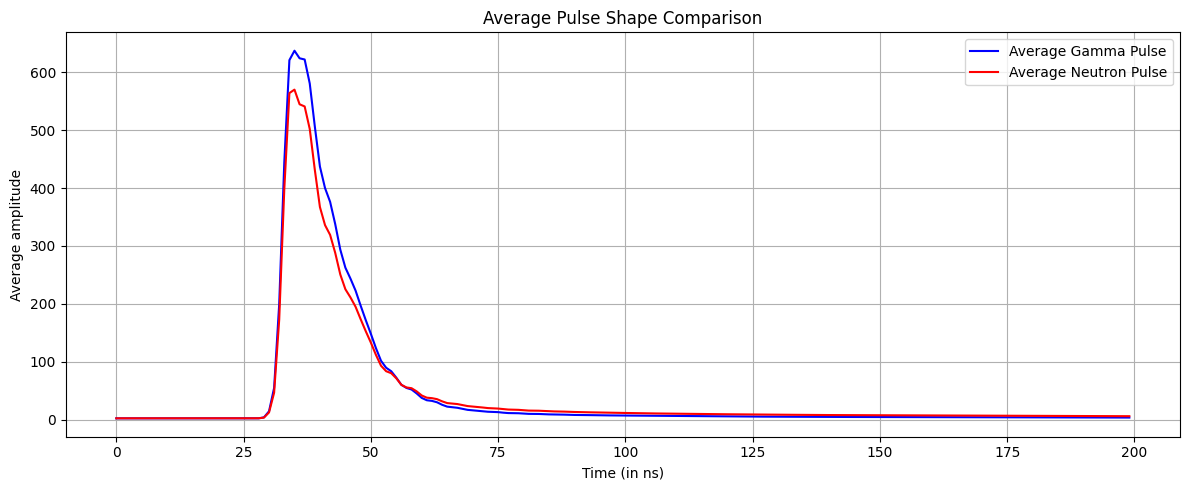

In [2]:
# Plotting the average gamma and neutron pulse (Kuneh)
import matplotlib.pyplot as plt
mean_waveform_gamma = df_expanded_gamma.mean(axis=0).iloc[:-1]
mean_waveform_neutron = df_expanded_neutron.mean(axis=0).iloc[:-1]
x = range(200)

plt.figure(figsize=(12, 5))
plt.plot(x, mean_waveform_gamma[0:200], color='blue', linewidth=1.5, label='Average Gamma Pulse')
plt.plot(x, mean_waveform_neutron[0:200], color='red', linewidth=1.5, label='Average Neutron Pulse')

plt.xlabel("Time (in ns)")
plt.ylabel("Average amplitude")
plt.title("Average Pulse Shape Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

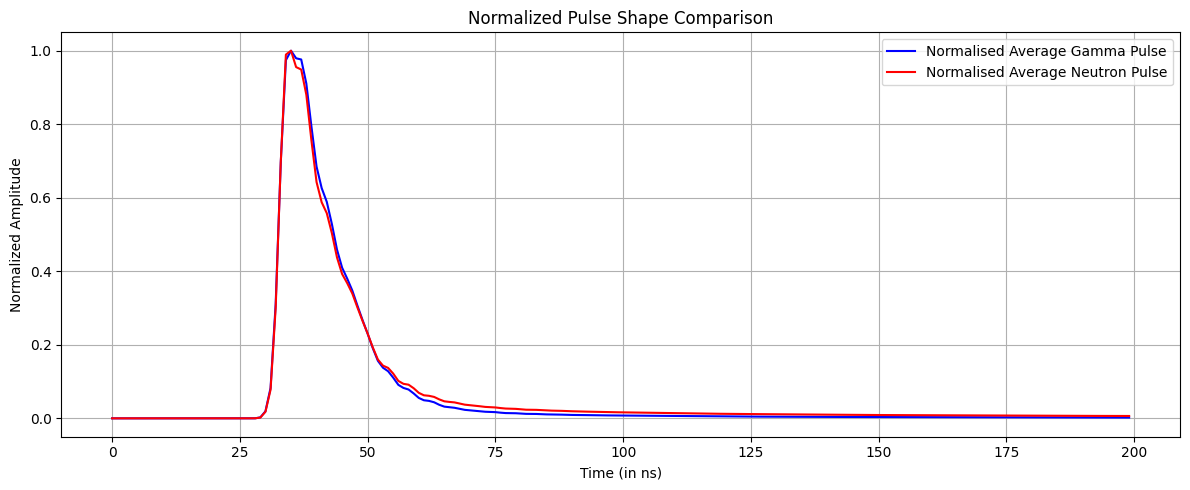

In [3]:
# Plotting the normalised average gamma and neutron pulse (Kuneh)
mean_waveform_gamma_norm = (mean_waveform_gamma -mean_waveform_gamma.min()) / (mean_waveform_gamma.max() - mean_waveform_gamma.min())
mean_waveform_neutron_norm = (mean_waveform_neutron -mean_waveform_neutron.min()) / (mean_waveform_neutron.max() - mean_waveform_neutron.min())

x = range(200)
plt.figure(figsize=(12, 5))
plt.plot(x, mean_waveform_gamma_norm[0:200], color='blue', linewidth=1.5, label='Normalised Average Gamma Pulse')
plt.plot(x, mean_waveform_neutron_norm[0:200], color='red', linewidth=1.5, label='Normalised Average Neutron Pulse')

plt.xlabel("Time (in ns)")
plt.ylabel("Normalized Amplitude")
plt.title("Normalized Pulse Shape Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Charge Comparison Method

0.4388488759556003 (np.float64(0.7932178080050032), np.float64(0.07854205753595989), np.float64(0.7618009849906191), np.float64(0.840343042526579)) (np.float64(0.7212772689791865), np.float64(0.08538803997007793), np.float64(0.6743138469956437), np.float64(0.7597018869657216))


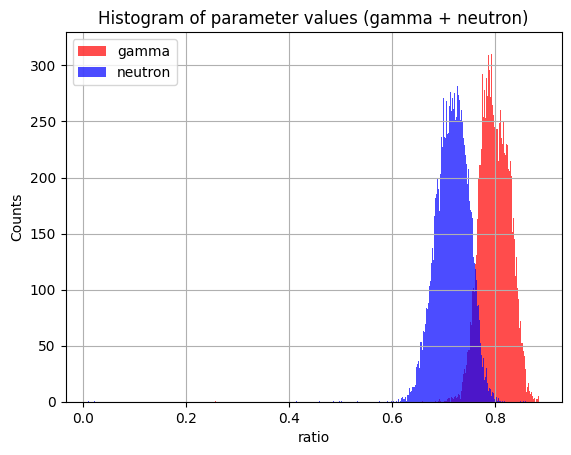

Split @ 55: Accuracy = 0.9304
Confusion Matrix:
 [[6446  328]
 [ 507 4720]]


In [4]:
# Basic CCM using Logistic Regression (Kuneh)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
def calculate_fom(gamma_data, neutron_data, bins=200):
    # Create histograms to find peaks and widths
    g_counts, g_edges = np.histogram(gamma_data, bins=bins)
    n_counts, n_edges = np.histogram(neutron_data, bins=bins)
    
    # Midpoints of bins for plotting/calculation
    g_mids = (g_edges[:-1] + g_edges[1:]) / 2
    n_mids = (n_edges[:-1] + n_edges[1:]) / 2
    
    def get_fwhm(counts, mids):
        peak_idx = np.argmax(counts)
        peak_val = counts[peak_idx]
        half_max = peak_val / 2
        
        # Find indices where counts cross half_max
        # Left side
        left_idx = np.where(counts[:peak_idx] <= half_max)[0]
        left_idx = left_idx[-1] if len(left_idx) > 0 else 0
        
        # Right side
        right_idx = np.where(counts[peak_idx:] <= half_max)[0]
        right_idx = (right_idx[0] + peak_idx) if len(right_idx) > 0 else len(counts) - 1
        
        fwhm = mids[right_idx] - mids[left_idx]
        return mids[peak_idx], fwhm, left_idx, right_idx

    g_peak, g_fwhm, g_l, g_r = get_fwhm(g_counts, g_mids)
    n_peak, n_fwhm, n_l, n_r = get_fwhm(n_counts, n_mids)
    
    manual_fom = abs(n_peak - g_peak) / (g_fwhm + n_fwhm)
    
    return manual_fom, (g_peak, g_fwhm, g_mids[g_l], g_mids[g_r]), (n_peak, n_fwhm, n_mids[n_l], n_mids[n_r])



short_start = 25
long_end = 105
splits = range(55, 56, 5)   

accuracies = []


for split in splits:

    gamma_short = df_expanded_gamma.iloc[:, short_start:split].sum(axis=1)
    gamma_long  = df_expanded_gamma.iloc[:, split:long_end].sum(axis=1)
    gamma_ratio = ((gamma_long - gamma_short) / (gamma_long + gamma_short)).abs()
    
 
    neutron_short = df_expanded_neutron.iloc[:, short_start:split].sum(axis=1)
    neutron_long  = df_expanded_neutron.iloc[:, split:long_end].sum(axis=1)
    neutron_ratio = ((neutron_long - neutron_short) / (neutron_long + neutron_short)).abs()
    fom_val, g_stats, n_stats = calculate_fom(gamma_ratio, neutron_ratio)
    print(fom_val, g_stats, n_stats)
    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([
        np.zeros(len(gamma_ratio)),   # gamma = 0
        np.ones(len(neutron_ratio))   # neutron = 1
    ])


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    plt.hist(gamma_ratio,label= 'gamma', bins=1000, alpha=0.7, color='red')
    plt.hist(neutron_ratio,label = 'neutron', bins=1000, alpha=0.7, color = 'blue')
    plt.xlabel("ratio")
    plt.ylabel("Counts")
    plt.title("Histogram of parameter values (gamma + neutron)")
    plt.legend()
    plt.grid(True)
    plt.show()

    clf = LogisticRegression()
    clf.fit(X_train, y_train)


    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Split @ {split}: Accuracy = {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# plt.figure(figsize=(10, 5))
# plt.plot(splits, accuracies, marker='o')
# plt.xlabel("Gate split index (short → long)")
# plt.ylabel("Classification accuracy")
# plt.title("PSD Gate Optimization for CCM")
# plt.grid(True)
# plt.tight_layout()
# plt.show()




Charge Weighted comparison Method

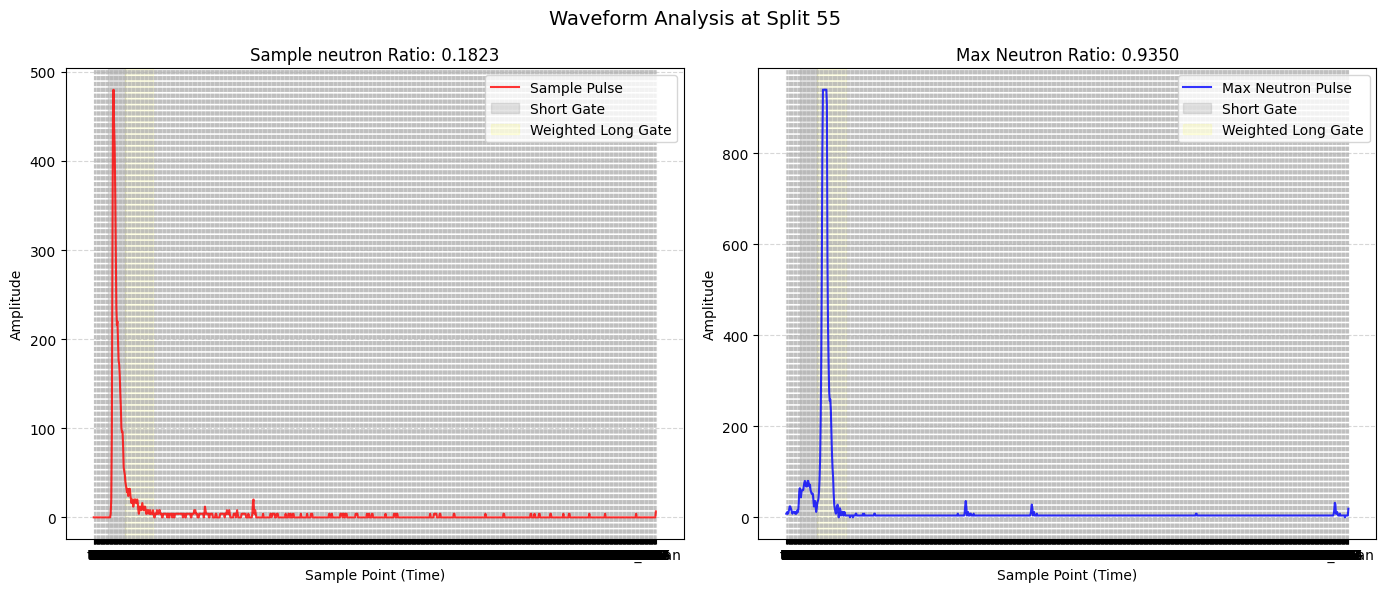

0.4265268682289674 (np.float64(0.17286277520946794), np.float64(0.06789707578319054), np.float64(0.12759805802067425), np.float64(0.1954951338038648)) (np.float64(0.23173235751133012), np.float64(0.07012373061126129), np.float64(0.1946080295406624), np.float64(0.2647317601519237))
Split @ 55: Accuracy = 0.9302
Confusion Matrix:
 [[6453  321]
 [ 517 4710]]


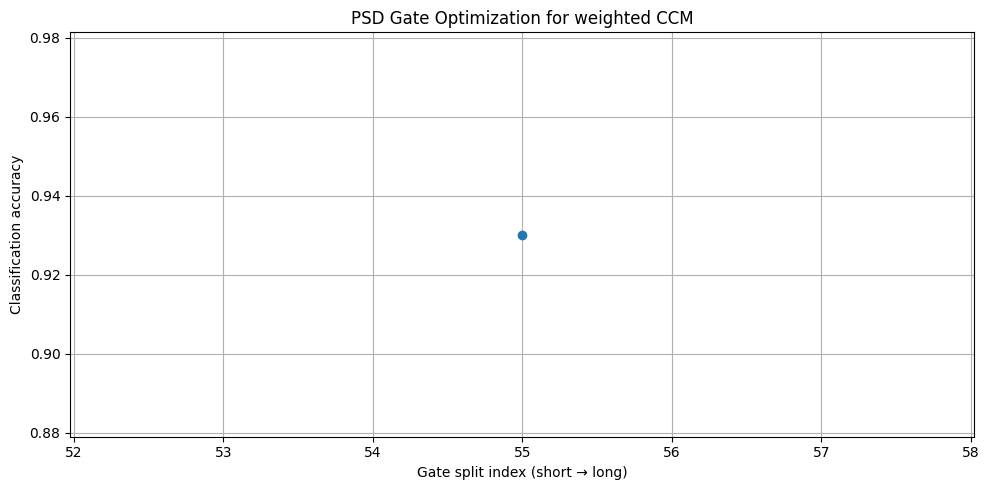

In [15]:
# Weighted CCM (Discrimination of neutron-gamma in the low energy regime using machine learning for an EJ-276D plastic scintillator by S.Panda et al.)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix


short_start = 25
long_end = 105
splits = range(55, 56, 5)   # 50, 55, 60, ..., 100

accuracies = []


for split in splits:

    gamma_short = df_expanded_gamma.iloc[:, short_start:split].values


    long_indices = np.arange(split, long_end)  # j = split, split+1, ...
    short_indices = np. arange(short_start,split)
    gamma_long_values = df_expanded_gamma.iloc[:, split:long_end].values
    weights = long_indices  
    weighted_long = (gamma_long_values * weights).sum(axis=1)
    weighted_short = (gamma_short * short_indices).sum(axis=1)
    # Weighted ratio
    gamma_ratio = weighted_long / (weighted_short+weighted_long)
    # print(max(gamma_ratio))

    neutron_short = df_expanded_neutron.iloc[:, short_start:split].values
    neutron_long_values = df_expanded_neutron.iloc[:, split:long_end].values
    weighted_long_neutron = (neutron_long_values * weights).sum(axis=1)
    weighted_short_neutron = (neutron_short * short_indices).sum(axis=1)
    neutron_ratio = weighted_long_neutron / (weighted_short_neutron+weighted_long_neutron)
    # print(max(neutron_ratio))


    # ... [Inside your for split in splits: loop] ...

    # 1. Get the indices of the max ratios
    # Use .values to ensure we get the integer position for iloc
    # max_gamma_idx = np.argmax(gamma_ratio)
    max_neutron_idx = np.argmax(neutron_ratio)

    # 2. Extract waveforms
    #pulse_gamma_max = df_expanded_gamma.iloc[max_gamma_idx, :]
    pulse_neutron_sample = df_expanded_neutron.iloc[3, :]
    pulse_neutron_max = df_expanded_neutron.iloc[max_neutron_idx, :]

    # 3. Create the comparison plot
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Plotting Gamma Max
    # ax[0].plot(pulse_gamma_max, color='red', alpha=0.8, label='Max Gamma Pulse')
    # ax[0].set_title(f"Max Gamma Ratio: {gamma_ratio[max_gamma_idx]:.4f}")
    ax[0].plot(pulse_neutron_sample, color='red', alpha=0.8, label='Sample Pulse')
    ax[0].set_title(f"Sample neutron Ratio: {gamma_ratio[3]:.4f}")

    # Plotting Neutron Max
    ax[1].plot(pulse_neutron_max, color='blue', alpha=0.8, label='Max Neutron Pulse')
    ax[1].set_title(f"Max Neutron Ratio: {neutron_ratio[max_neutron_idx]:.4f}")

    # Overlay Gate indicators on both
    for i in range(2):
        ax[i].axvspan(short_start, split, color='gray', alpha=0.2, label='Short Gate')
        ax[i].axvspan(split, long_end, color='yellow', alpha=0.1, label='Weighted Long Gate')
        ax[i].set_xlabel("Sample Point (Time)")
        ax[i].set_ylabel("Amplitude")
        ax[i].legend()
        ax[i].grid(True, which='both', linestyle='--', alpha=0.5)

    plt.suptitle(f"Waveform Analysis at Split {split}", fontsize=14)
    plt.tight_layout()
    plt.show()

    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([
        np.zeros(len(gamma_ratio)),   # gamma = 0
        np.ones(len(neutron_ratio))   # neutron = 1
    ])
    fom_val, g_stats, n_stats = calculate_fom(gamma_ratio, neutron_ratio)
    print(fom_val, g_stats, n_stats)
    # plt.hist(gamma_ratio,label= 'gamma', bins=1000, alpha=0.7, color='red')
    # plt.hist(neutron_ratio,label = 'neutron', bins=1000, alpha=0.7, color = 'blue')
    # # plt.xlim(0,30)
    # plt.xlabel("ratio")
    # plt.ylabel("Counts")
    # plt.title("Histogram of parameter values (gamma + neutron)")
    # plt.legend()
    # plt.grid(True)
    # plt.show()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )


    clf = LogisticRegression()
    clf.fit(X_train, y_train)


    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Split @ {split}: Accuracy = {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.figure(figsize=(10, 5))
plt.plot(splits, accuracies, marker='o')
plt.xlabel("Gate split index (short → long)")
plt.ylabel("Classification accuracy")
plt.title("PSD Gate Optimization for weighted CCM")
plt.grid(True)
plt.tight_layout()
plt.show()



Time domain


==================== GAMMA SUMMARY ====================
Mean Width: 13.84 | Median: 14.00
Min Width:  7.00 | Max Width: 22.00


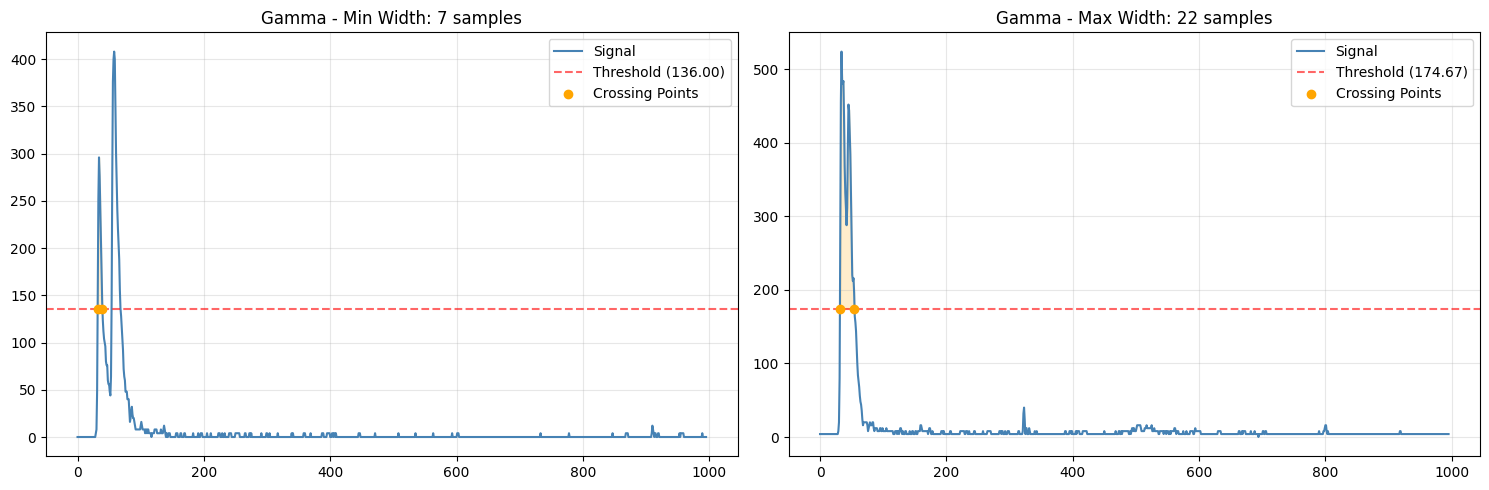

       t0  t1  t2  t3  t4  t5  t6  t7  t8  t9  ...  t991  t992  t993  t994  \
0       4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4   
1       4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4   
2       0   0   0   0   0   0   0   0   0   0  ...     0     0     0     0   
3       4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4   
4       4   4   4   4   0   4   4   4   4   4  ...     4     4     4     4   
...    ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   ...   ...   ...   ...   
33863   0   0   0   0   0   0   0   0   0   0  ...     0     0     4     4   
33864   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4   
33865   0   0   0   0   0   0   0   0   0   0  ...     0     0     0     0   
33866   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     8   
33867   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4   

       t995     t_mean  width_1_3  start_idx_1_3  end_idx_1_3  

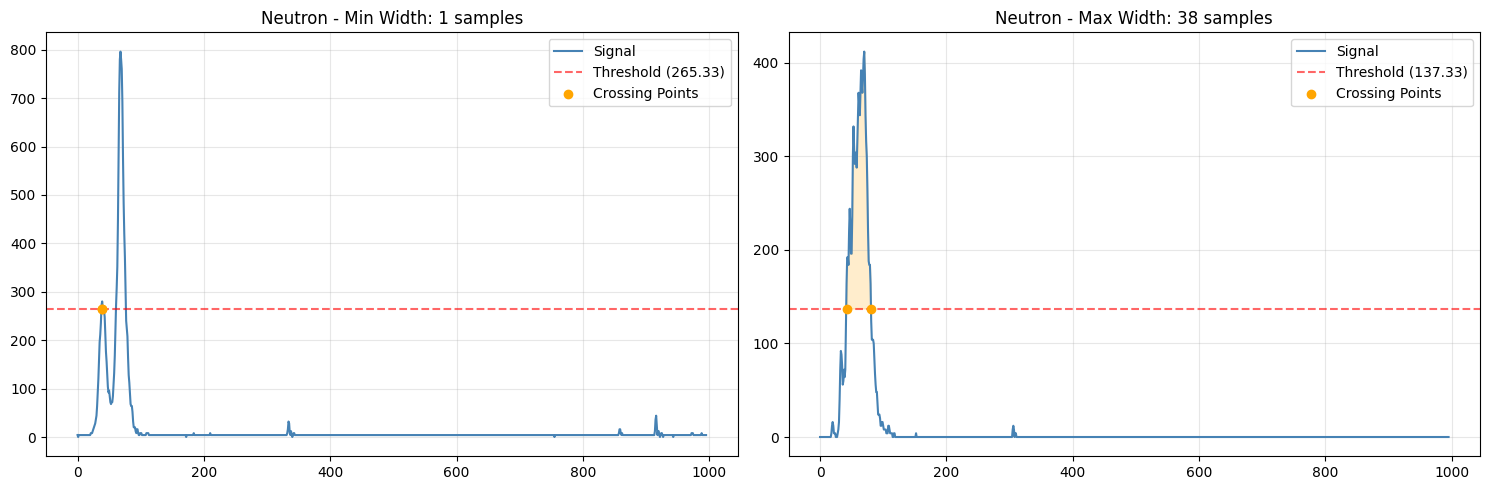

       t0  t1  t2  t3  t4  t5  t6  t7  t8  t9  ...  t991  t992  t993  t994  \
0       4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4   
1       0   0   0   0   0   0   0   0   0   0  ...     0     0     0     0   
2       0   0   0   0   0   0   0   0   0   0  ...     0     0     0     0   
3       0   0   0   0   0   0   0   0   0   0  ...     0     0     0     0   
4       4   4   4   4   4   4   4   4   4   4  ...     8     8     4     4   
...    ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   ...   ...   ...   ...   
26131   8   4   4   4   4   4   4   4   4   4  ...     4     4     4     4   
26132   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4   
26133   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4   
26134   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4   
26135   4   4   4   4   4   4   4   4   0   4  ...     4     4     4     4   

       t995     t_mean  max_val  width_1_3  start_idx_1_3  end_

In [56]:
#Time domain analysis of neutron and gamma samples for width at 1/3rd of maximum height
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_plot_extremes(df, label, threshold_ratio=1/3):
    t_cols = [f't{i}' for i in range(996)]
    t_data_vals = df[t_cols].values
    
    max_vals = np.max(t_data_vals, axis=1)
    df['max_val']= max_vals
    thresholds = max_vals * threshold_ratio
    
    starts, ends, widths = [], [], []

    for i, row in enumerate(t_data_vals):
        above_thresh = row > thresholds[i]
        if np.any(above_thresh):
            start = np.argmax(above_thresh)
            remaining = above_thresh[start:]
            # Find first index where it drops back below
            if np.any(~remaining):
                end = start + np.argmax(~remaining) - 1
            else:
                end = len(row) - 1
            starts.append(start); ends.append(end); widths.append(end - start)
        else:
            starts.append(None); ends.append(None); widths.append(None)

    df['width_1_3'], df['start_idx_1_3'], df['end_idx_1_3'] = widths, starts, ends
    
    # --- Summary Statistics ---
    valid_indices = df.index[df['width_1_3'].notna()]
    valid_widths = df.loc[valid_indices, 'width_1_3']
    
    print(f"\n{'='*20} {label.upper()} SUMMARY {'='*20}")
    print(f"Mean Width: {valid_widths.mean():.2f} | Median: {valid_widths.median():.2f}")
    print(f"Min Width:  {valid_widths.min():.2f} | Max Width: {valid_widths.max():.2f}")

    # --- Plotting Extremes ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Get indices for absolute min and max width
    idx_min = valid_widths.idxmin()
    idx_max = valid_widths.idxmax()
    
    for ax, target_idx, title_prefix in zip(axes, [idx_min, idx_max], ["Min Width", "Max Width"]):
        row_data = df.loc[target_idx, t_cols].values
        thr = df.loc[target_idx, 'max_val'] * threshold_ratio
        s, e = int(df.loc[target_idx, 'start_idx_1_3']), int(df.loc[target_idx, 'end_idx_1_3'])
        
        ax.plot(row_data, label='Signal', color='steelblue')
        ax.axhline(thr, color='red', linestyle='--', alpha=0.6, label=f'Threshold ({thr:.2f})')
        ax.scatter([s, e], [thr, thr], color='orange', zorder=5, label='Crossing Points')
        ax.fill_between(range(s, e+1), row_data[s:e+1], thr, color='orange', alpha=0.2)
        
        ax.set_title(f"{label} - {title_prefix}: {df.loc[target_idx, 'width_1_3']} samples")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return df

# Run for both
df_expanded_gamma = analyze_and_plot_extremes(df_expanded_gamma, "Gamma")
print(df_expanded_gamma)
df_expanded_neutron = analyze_and_plot_extremes(df_expanded_neutron, "Neutron")
print(df_expanded_neutron)

Maximum values and 1/3 threshold analysis (first 10 rows):
   max_value_t0_t995 max_column_t0_t995  threshold_1_3  start_idx_1_3  \
0                792                t34     264.000000             32   
1                752                t34     250.666667             33   
2                648                t35     216.000000             32   
3                464                t34     154.666667             32   
4                764                t35     254.666667             33   
5                784                t35     261.333333             33   
6                488                t36     162.666667             32   
7                440                t37     146.666667             32   
8                716                t35     238.666667             33   
9                460                t34     153.333333             32   

   end_idx_1_3  width_at_1_3  max_index_numeric  
0           46            14                 34  
1           47            14         

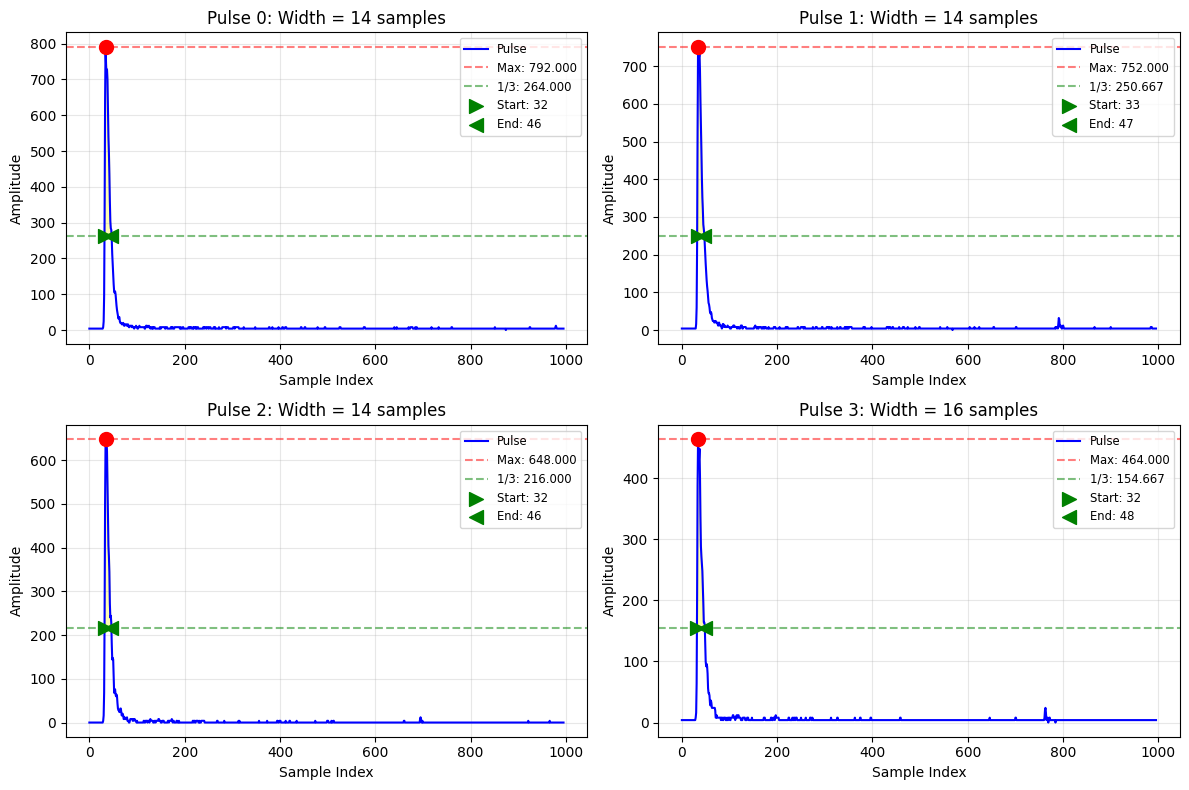


Added new columns to df_expanded_gamma:
Columns added: ['max_value', 'max_column', 'threshold_1_3', 'start_idx_1_3', 'end_idx_1_3', 'width_at_1_3']


In [ ]:
# # Select t0 through t995 columns
# t_cols = [f't{i}' for i in range(996)]

# # Get the subset DataFrame
# t_data = df_expanded_gamma[t_cols]

# # Get maximum value per row
# max_values = t_data.max(axis=1)

# # Get column name where maximum occurs
# max_columns = t_data.idxmax(axis=1)

# # Calculate 1/3 of maximum value for each row
# threshold_values = max_values / 3

# # Function to find crossing points at threshold
# def find_threshold_crossings(row_values, threshold):
#     """Find indices where signal crosses the threshold value"""
#     above_threshold = row_values > threshold
    
#     start_idx = None
#     end_idx = None
    

#     for i, val in enumerate(above_threshold):
#         if val and start_idx is None:
#             start_idx = i  # First time above threshold
#         elif not val and start_idx is not None:
#             end_idx = i - 1  # End of the first above-threshold segment
#             break
    
#     # If waveform stays above threshold until the end
#     if start_idx is not None and end_idx is None:
#         end_idx = len(row_values) - 1
    
#     if start_idx is None:
#         return None, None, None
    
#     width = end_idx - start_idx
#     return start_idx, end_idx, width

# # Find crossings for each row
# start_indices = []
# end_indices = []
# widths = []

# for idx, row in t_data.iterrows():
#     start, end, width = find_threshold_crossings(row.values, threshold_values.iloc[idx])
#     start_indices.append(start)
#     end_indices.append(end)
#     widths.append(width)

# # Create a DataFrame with all information
# max_info = pd.DataFrame({
#     'max_value_t0_t995': max_values,
#     'max_column_t0_t995': max_columns,
#     'threshold_1_3': threshold_values,
#     'start_idx_1_3': start_indices,
#     'end_idx_1_3': end_indices,
#     'width_at_1_3': widths
# })

# # Convert column name to numeric index
# max_info['max_index_numeric'] = max_info['max_column_t0_t995'].str.replace('t', '').astype(int)

# print("Maximum values and 1/3 threshold analysis (first 10 rows):")
# print(max_info.head(10))

# # Statistics summary
# print("\n" + "="*70)
# print("1/3 THRESHOLD ANALYSIS SUMMARY")
# print("="*70)
# print(f"Total pulses analyzed: {len(t_data)}")

# # Count pulses that reach the threshold
# valid_pulses = max_info['width_at_1_3'].notna()
# num_valid = valid_pulses.sum()
# print(f"Pulses that reach 1/3 threshold: {num_valid} ({num_valid/len(t_data)*100:.1f}%)")

# if num_valid > 0:
#     valid_widths = max_info.loc[valid_pulses, 'width_at_1_3']
#     print(f"\nWidth at 1/3 of maximum:")
#     print(f"  Mean width: {valid_widths.mean():.2f} samples")
#     print(f"  Std deviation: {valid_widths.std():.2f} samples")
#     print(f"  Minimum width: {valid_widths.min():.2f} samples")
#     print(f"  Maximum width: {valid_widths.max():.2f} samples")
#     print(f"  Median width: {valid_widths.median():.2f} samples")

# print(f"\nThreshold values (1/3 of max):")
# print(f"  Mean: {threshold_values.mean():.6f}")
# print(f"  Range: {threshold_values.min():.6f} to {threshold_values.max():.6f}")

# # Ratio check
# print(f"\nRatio analysis:")
# actual_ratio = (threshold_values / max_values).mean()
# print(f"  Actual mean (threshold/max): {actual_ratio:.6f}")
# print(f"  Expected: 0.333333")
# print(f"  Difference: {abs(actual_ratio - 1/3):.6f}")
# print("="*70)

# # Optional: Visualization of a few example pulses
# import matplotlib.pyplot as plt

# # Plot first 4 pulses as examples
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes = axes.ravel()

# for i in range(min(4, len(t_data))):
#     # Get pulse data
#     pulse_data = t_data.iloc[i].values
#     max_val = max_values.iloc[i]
#     threshold = threshold_values.iloc[i]
#     max_col = max_columns.iloc[i]
#     max_idx = int(max_col.replace('t', ''))
#     start_idx = start_indices[i]
#     end_idx = end_indices[i]
#     width = widths[i]
    
#     # Plot
#     axes[i].plot(range(996), pulse_data, 'b-', linewidth=1.5, label='Pulse')
#     axes[i].axhline(y=max_val, color='r', linestyle='--', alpha=0.5, label=f'Max: {max_val:.3f}')
#     axes[i].axhline(y=threshold, color='g', linestyle='--', alpha=0.5, label=f'1/3: {threshold:.3f}')
    
#     # Mark maximum point
#     axes[i].scatter(max_idx, max_val, color='red', s=100, zorder=5)
    
#     # Mark crossing points if they exist
#     if start_idx is not None and end_idx is not None:
#         axes[i].scatter(start_idx, threshold, color='green', s=100, marker='>', zorder=5, label=f'Start: {start_idx}')
#         axes[i].scatter(end_idx, threshold, color='green', s=100, marker='<', zorder=5, label=f'End: {end_idx}')
        
#         # Fill area above threshold
#         axes[i].fill_between(range(996), pulse_data, threshold, 
#                            where=(pulse_data > threshold), 
#                            color='yellow', alpha=0.3)
        
#         title = f'Pulse {i}: Width = {width} samples'
#     else:
#         title = f'Pulse {i}: Below threshold'
    
#     axes[i].set_title(title)
#     axes[i].set_xlabel('Sample Index')
#     axes[i].set_ylabel('Amplitude')
#     axes[i].legend(loc='upper right', fontsize='small')
#     axes[i].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Add the information back to original DataFrame if needed
# df_expanded_gamma['max_value'] = max_values
# df_expanded_gamma['max_column'] = max_columns
# df_expanded_gamma['threshold_1_3'] = threshold_values
# df_expanded_gamma['start_idx_1_3'] = start_indices
# df_expanded_gamma['end_idx_1_3'] = end_indices
# df_expanded_gamma['width_at_1_3'] = widths

# print("\nAdded new columns to df_expanded_gamma:")
# new_cols = ['max_value', 'max_column', 'threshold_1_3', 'start_idx_1_3', 'end_idx_1_3', 'width_at_1_3']
# print(f"Columns added: {new_cols}")

31 start_idx
56 end_idx
32 start_idx
55 end_idx
31 start_idx
54 end_idx
31 start_idx
57 end_idx
32 start_idx
56 end_idx
32 start_idx
57 end_idx
31 start_idx
53 end_idx
31 start_idx
51 end_idx
32 start_idx
53 end_idx
31 start_idx
54 end_idx
31 start_idx
55 end_idx
32 start_idx
54 end_idx
32 start_idx
54 end_idx
32 start_idx
54 end_idx
31 start_idx
56 end_idx
32 start_idx
56 end_idx
32 start_idx
56 end_idx
32 start_idx
54 end_idx
32 start_idx
55 end_idx
32 start_idx
56 end_idx
32 start_idx
56 end_idx
32 start_idx
55 end_idx
32 start_idx
57 end_idx
31 start_idx
55 end_idx
32 start_idx
56 end_idx
31 start_idx
54 end_idx
32 start_idx
54 end_idx
31 start_idx
53 end_idx
32 start_idx
56 end_idx
31 start_idx
51 end_idx
32 start_idx
56 end_idx
31 start_idx
57 end_idx
32 start_idx
55 end_idx
32 start_idx
57 end_idx
31 start_idx
57 end_idx
32 start_idx
55 end_idx
32 start_idx
55 end_idx
32 start_idx
54 end_idx
31 start_idx
56 end_idx
31 start_idx
55 end_idx
32 start_idx
55 end_idx
32 start_idx
55 

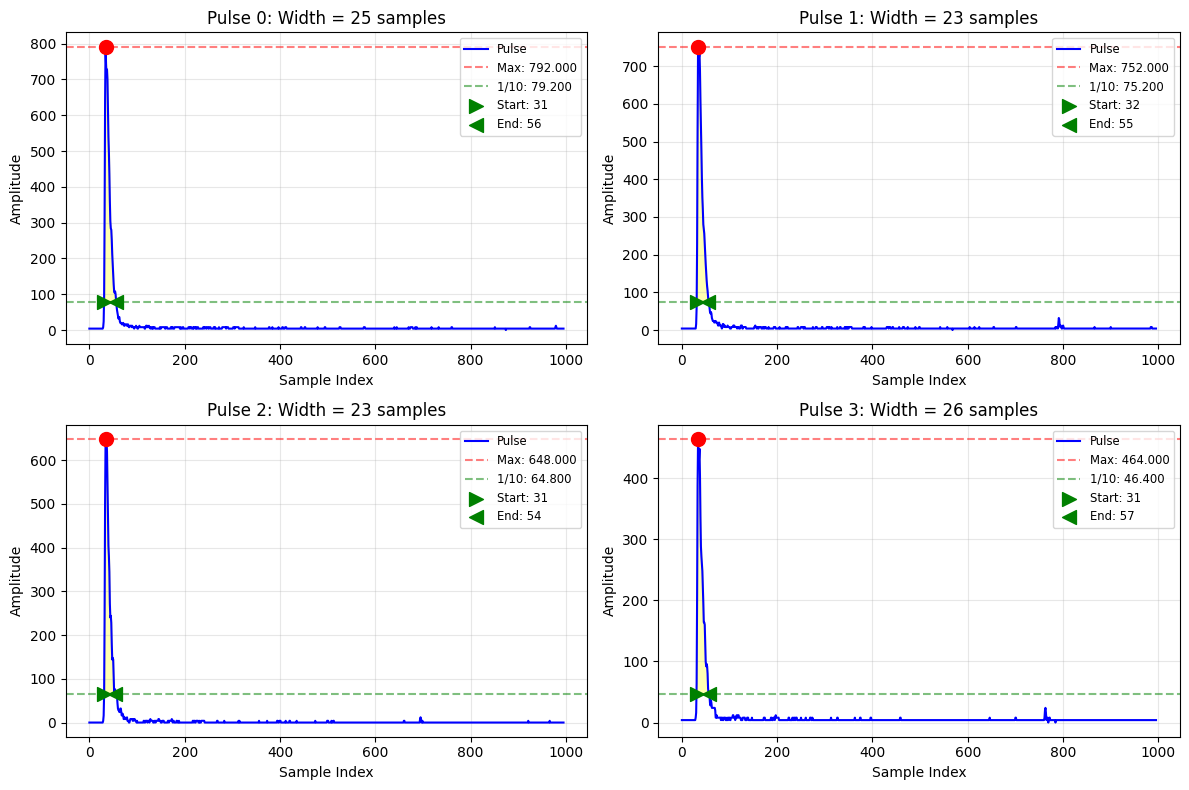


Added new columns to df_expanded_gamma:
Columns added: ['max_value', 'max_column', 'threshold_1_10', 'start_idx_1_10', 'end_idx_1_10', 'width_at_1_10']


In [ ]:
# # Select t0 through t995 columns
# t_cols = [f't{i}' for i in range(996)]

# # Get the subset DataFrame
# t_data = df_expanded_gamma[t_cols]

# # Get maximum value per row
# max_values = t_data.max(axis=1)

# # Get column name where maximum occurs
# max_columns = t_data.idxmax(axis=1)

# # Calculate 1/3 of maximum value for each row
# threshold_values = max_values / 10


# # Find crossings for each row
# start_indices = []
# end_indices = []
# widths = []

# for idx, row in t_data.iterrows():
#     start, end, width = find_threshold_crossings(row.values, threshold_values.iloc[idx])
#     start_indices.append(start)
#     end_indices.append(end)
#     widths.append(width)

# # Create a DataFrame with all information
# max_info = pd.DataFrame({
#     'max_value_t0_t995': max_values,
#     'max_column_t0_t995': max_columns,
#     'threshold_1_10': threshold_values,
#     'start_idx_1_10': start_indices,
#     'end_idx_1_10': end_indices,
#     'width_at_1_10': widths
# })

# # Convert column name to numeric index
# max_info['max_index_numeric'] = max_info['max_column_t0_t995'].str.replace('t', '').astype(int)

# print("Maximum values and 1/10 threshold analysis (first 10 rows):")
# print(max_info.head(10))

# # Statistics summary
# print("\n" + "="*70)
# print("1/10 THRESHOLD ANALYSIS SUMMARY")
# print("="*70)
# print(f"Total pulses analyzed: {len(t_data)}")

# # Count pulses that reach the threshold
# valid_pulses = max_info['width_at_1_10'].notna()
# num_valid = valid_pulses.sum()
# print(f"Pulses that reach 1/10 threshold: {num_valid} ({num_valid/len(t_data)*100:.1f}%)")

# if num_valid > 0:
#     valid_widths = max_info.loc[valid_pulses, 'width_at_1_10']
#     print(f"\nWidth at 1/10 of maximum:")
#     print(f"  Mean width: {valid_widths.mean():.2f} samples")
#     print(f"  Std deviation: {valid_widths.std():.2f} samples")
#     print(f"  Minimum width: {valid_widths.min():.2f} samples")
#     print(f"  Maximum width: {valid_widths.max():.2f} samples")
#     print(f"  Median width: {valid_widths.median():.2f} samples")

# print(f"\nThreshold values (1/10 of max):")
# print(f"  Mean: {threshold_values.mean():.6f}")
# print(f"  Range: {threshold_values.min():.6f} to {threshold_values.max():.6f}")

# # Ratio check
# print(f"\nRatio analysis:")
# actual_ratio = (threshold_values / max_values).mean()
# print(f"  Actual mean (threshold/max): {actual_ratio:.6f}")
# print(f"  Expected: 0.333333")
# print(f"  Difference: {abs(actual_ratio - 1/10):.6f}")
# print("="*70)

# # Optional: Visualization of a few example pulses
# import matplotlib.pyplot as plt

# # Plot first 4 pulses as examples
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes = axes.ravel()

# for i in range(min(4, len(t_data))):
#     # Get pulse data
#     pulse_data = t_data.iloc[i].values
#     max_val = max_values.iloc[i]
#     threshold = threshold_values.iloc[i]
#     max_col = max_columns.iloc[i]
#     max_idx = int(max_col.replace('t', ''))
#     start_idx = start_indices[i]
#     end_idx = end_indices[i]
#     width = widths[i]
    
#     # Plot
#     axes[i].plot(range(996), pulse_data, 'b-', linewidth=1.5, label='Pulse')
#     axes[i].axhline(y=max_val, color='r', linestyle='--', alpha=0.5, label=f'Max: {max_val:.3f}')
#     axes[i].axhline(y=threshold, color='g', linestyle='--', alpha=0.5, label=f'1/10: {threshold:.3f}')
    
#     # Mark maximum point
#     axes[i].scatter(max_idx, max_val, color='red', s=100, zorder=5)
    
#     # Mark crossing points if they exist
#     if start_idx is not None and end_idx is not None:
#         axes[i].scatter(start_idx, threshold, color='green', s=100, marker='>', zorder=5, label=f'Start: {start_idx}')
#         axes[i].scatter(end_idx, threshold, color='green', s=100, marker='<', zorder=5, label=f'End: {end_idx}')
        
#         # Fill area above threshold
#         axes[i].fill_between(range(996), pulse_data, threshold, 
#                            where=(pulse_data > threshold), 
#                            color='yellow', alpha=0.3)
        
#         title = f'Pulse {i}: Width = {width} samples'
#     else:
#         title = f'Pulse {i}: Below threshold'
    
#     axes[i].set_title(title)
#     axes[i].set_xlabel('Sample Index')
#     axes[i].set_ylabel('Amplitude')
#     axes[i].legend(loc='upper right', fontsize='small')
#     axes[i].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Add the information back to original DataFrame if needed
# df_expanded_gamma['max_value'] = max_values
# df_expanded_gamma['max_column'] = max_columns
# df_expanded_gamma['threshold_1_10'] = threshold_values
# df_expanded_gamma['start_idx_1_10'] = start_indices
# df_expanded_gamma['end_idx_1_10'] = end_indices
# df_expanded_gamma['width_at_1_10'] = widths

# print("\nAdded new columns to df_expanded_gamma:")
# new_cols = ['max_value', 'max_column', 'threshold_1_10', 'start_idx_1_10', 'end_idx_1_10', 'width_at_1_10']
# print(f"Columns added: {new_cols}")

Non-Gaussian Fluctuation Parameter

   t0  t1  t2  t3  t4  t5  t6  t7  t8  t9  ...     t_mean  width_1_3  \
0   4   4   4   4   4   4   4   4   4   4  ...  14.706827         14   
1   4   4   4   4   4   4   4   4   4   4  ...  14.522088         14   
2   0   0   0   0   0   0   0   0   0   0  ...   8.662651         14   
3   4   4   4   4   4   4   4   4   4   4  ...  10.598394         16   
4   4   4   4   4   0   4   4   4   4   4  ...  15.357430         16   

   start_idx_1_3  end_idx_1_3  max_val       kappa_1      kappa_2  \
0             32           46      792 -1.638350e-13  4809.347785   
1             33           47      752  2.369903e-14  4568.900115   
2             32           46      648  1.045554e-13  3227.464509   
3             32           48      464  1.062158e-13  1712.461202   
4             33           49      764  1.460037e-13  5054.751762   

        kappa_3       kappa_4      parameter  
0  2.856900e+06  1.866678e+09  388135.407189  
1  2.659522e+06  1.714511e+09  375256.932829  
2  1.615353

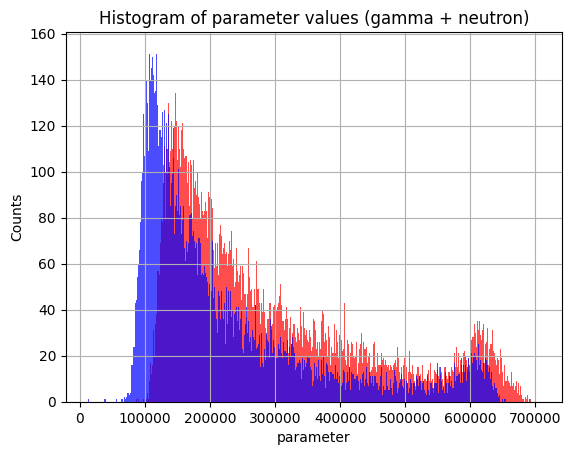

Accuracy = 0.6339
Confusion Matrix:
 [[5148 1626]
 [2768 2459]]


In [58]:
import numpy as np
t_cols_gamma = df_expanded_gamma.filter(regex=r'^t\d+$').columns
N = len(t_cols_gamma)

delta = df_expanded_gamma[t_cols_gamma].sub(
    df_expanded_gamma["t_mean"],
    axis=0
)
k1_gamma = (delta ** 1).sum(axis=1) / N
k2_gamma = (delta ** 2).sum(axis=1) / N
k3_gamma = (delta ** 3).sum(axis=1) / N
k4_gamma = (delta ** 4).sum(axis=1) / N

df_expanded_gamma["kappa_1"] = k1_gamma
df_expanded_gamma["kappa_2"] = k2_gamma
df_expanded_gamma["kappa_3"] = k3_gamma
df_expanded_gamma["kappa_4"] = k4_gamma
df_expanded_gamma["parameter"] = (k4_gamma/k2_gamma )
print(df_expanded_gamma.head())


import numpy as np
t_cols_neutron = df_expanded_neutron.filter(regex=r'^t\d+$').columns
N = len(t_cols_neutron)

delta = df_expanded_neutron[t_cols_neutron].sub(
    df_expanded_neutron["t_mean"],
    axis=0
)
k1_neutron = (delta ** 1).sum(axis=1) / N
k2_neutron = (delta ** 2).sum(axis=1) / N
k3_neutron = (delta ** 3).sum(axis=1) / N
k4_neutron = (delta ** 4).sum(axis=1) / N
df_expanded_neutron["kappa_1"] = k1_neutron
df_expanded_neutron["kappa_2"] = k2_neutron
df_expanded_neutron["kappa_3"] = k3_neutron
df_expanded_neutron["kappa_4"] = k4_neutron
df_expanded_neutron["parameter"] = (k4_neutron/k2_neutron)
print(df_expanded_neutron.head())


gamma_param = df_expanded_gamma["parameter"]
neutron_param =  df_expanded_neutron["parameter"]


# ---- Dataset ----
X = np.concatenate([gamma_param, neutron_param]).reshape(-1, 1)
y = np.concatenate([
    np.zeros(len(gamma_param)),    # gamma = 0
    np.ones(len(neutron_param))    # neutron = 1
])
plt.hist(df_expanded_gamma["parameter"], bins=1000, alpha=0.7, color='red')
plt.hist(df_expanded_neutron["parameter"], bins=1000, alpha=0.7, color = 'blue')
plt.xlabel("parameter")
plt.ylabel("Counts")
plt.title("Histogram of parameter values (gamma + neutron)")
plt.grid(True)
plt.show()



# ---- Train / test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ---- Train / test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---- Logistic Regression ----
clf = LogisticRegression()
clf.fit(X_train, y_train)

# ---- Accuracy ----
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
accuracies.append(acc)

print(f"Accuracy = {acc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# # Get the index of the row with max value
# max_row_index_neutron = df_expanded_neutron['width_at_1_10'].idxmax()
# max_row_index_gamma = df_expanded_gamma['width_at_1_10'].idxmax()

# print(f"Neutron max row index: {max_row_index_neutron}")
# print(f"Gamma max row index: {max_row_index_gamma}")



# # For a single column
# print(df_expanded_neutron['width_at_1_10'].max())
# print(df_expanded_gamma['width_at_1_10'].max())


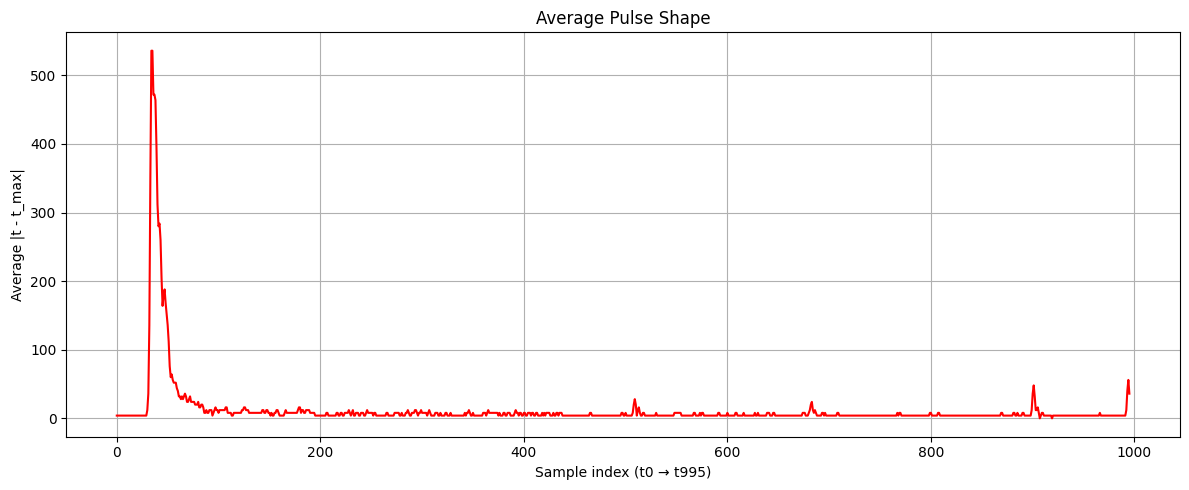

In [ ]:

# Compute column-wise mean
t_cols = [f't{i}' for i in range(996)]
df_expanded_neutron = df_expanded_neutron[t_cols]
df_expanded_gamma = df_expanded_gamma[t_cols]
neutron_row = df_expanded_neutron.loc[1533]
gamma_row = df_expanded_gamma.loc[11191]



plt.figure(figsize=(12, 5))
#plt.plot(range(len(gamma_row)), gamma_row, color='blue', linewidth=1.5)
plt.plot(range(len(neutron_row)), neutron_row, color='red', linewidth=1.5)
plt.xlabel("Sample index (t0 → t995)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape")
plt.grid(True)
plt.tight_layout()
plt.show()
# Plot

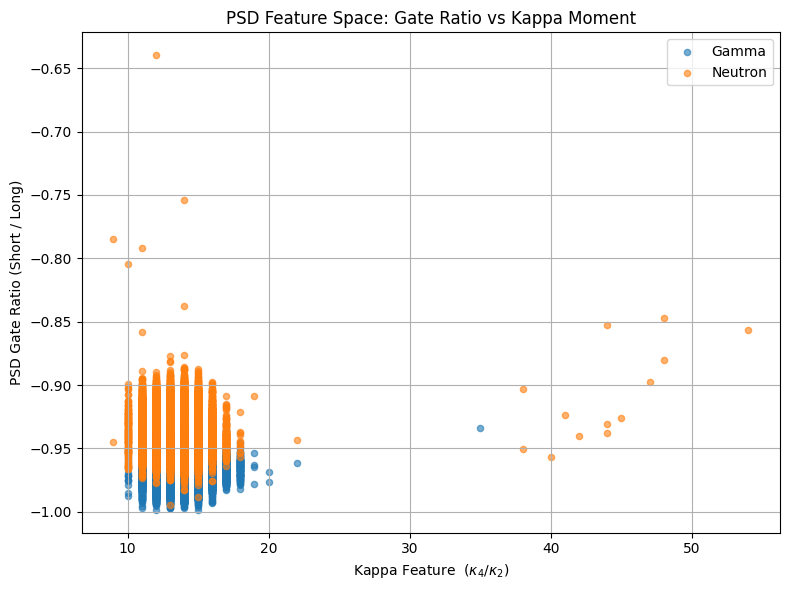

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# USER PARAMETERS
# ======================================
short_start = 25
long_end = 105
split = 55         # choose best/physical split

# ======================================
# PART 1: PSD GATE RATIO (Y-AXIS)
# ======================================



# ======================================
# PART 2: KAPPA MOMENT FEATURE (X-AXIS)
# ======================================



gamma_kappa = df_expanded_gamma["width_at_1_3"] # or use k4_gamma directly

neutron_kappa = df_expanded_neutron["width_at_1_3"]


# ======================================
# SANITY CHECK
# ======================================
assert len(gamma_ratio) == len(gamma_kappa), "Gamma size mismatch"
assert len(neutron_ratio) == len(neutron_kappa), "Neutron size mismatch"

# ======================================
# PART 3: 2D SCATTER PLOT
# ======================================

plt.figure(figsize=(8, 6))

plt.scatter(
    gamma_kappa,
    gamma_ratio,
    s=20,
    alpha=0.6,
    label="Gamma",

)

plt.scatter(
    neutron_kappa,
    neutron_ratio,
    s=20,
    alpha=0.6,
    label="Neutron"
)

plt.xlabel(r"Kappa Feature  ($\kappa_4 / \kappa_2$)")
plt.ylabel("PSD Gate Ratio (Short / Long)")
plt.title("PSD Feature Space: Gate Ratio vs Kappa Moment")
plt.legend()
plt.grid(True)

# Optional: log scaling (often improves PSD separation)
# plt.xscale("log")
# plt.yscale("log")

plt.tight_layout()
plt.show()


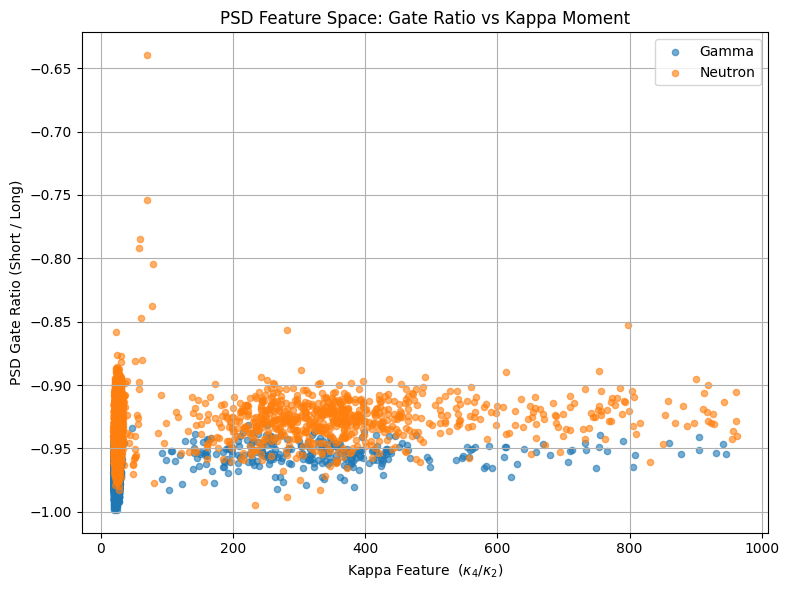

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# USER PARAMETERS
# ======================================
short_start = 25
long_end = 105
split = 55         # choose best/physical split

# ======================================
# PART 1: PSD GATE RATIO (Y-AXIS)
# ======================================



# ======================================
# PART 2: KAPPA MOMENT FEATURE (X-AXIS)
# ======================================



gamma_kappa = df_expanded_gamma["width_at_1_10"] # or use k4_gamma directly

neutron_kappa = df_expanded_neutron["width_at_1_10"]


# ======================================
# SANITY CHECK
# ======================================
assert len(gamma_ratio) == len(gamma_kappa), "Gamma size mismatch"
assert len(neutron_ratio) == len(neutron_kappa), "Neutron size mismatch"

# ======================================
# PART 3: 2D SCATTER PLOT
# ======================================

plt.figure(figsize=(8, 6))

plt.scatter(
    gamma_kappa,
    gamma_ratio,
    s=20,
    alpha=0.6,
    label="Gamma",

)

plt.scatter(
    neutron_kappa,
    neutron_ratio,
    s=20,
    alpha=0.6,
    label="Neutron"
)

plt.xlabel(r"Kappa Feature  ($\kappa_4 / \kappa_2$)")
plt.ylabel("PSD Gate Ratio (Short / Long)")
plt.title("PSD Feature Space: Gate Ratio vs Kappa Moment")
plt.legend()
plt.grid(True)

# Optional: log scaling (often improves PSD separation)
# plt.xscale("log")
# plt.yscale("log")

plt.tight_layout()
plt.show()
